 MEMULAI ANALISIS KUALITAS SINYAL EEG (CSV)


C:\Users\Steven Tjhia\AppData\Local\Temp\ipykernel_6004\3375081401.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_q_melt, x='Channel', y='Score', palette='viridis', errorbar=None)


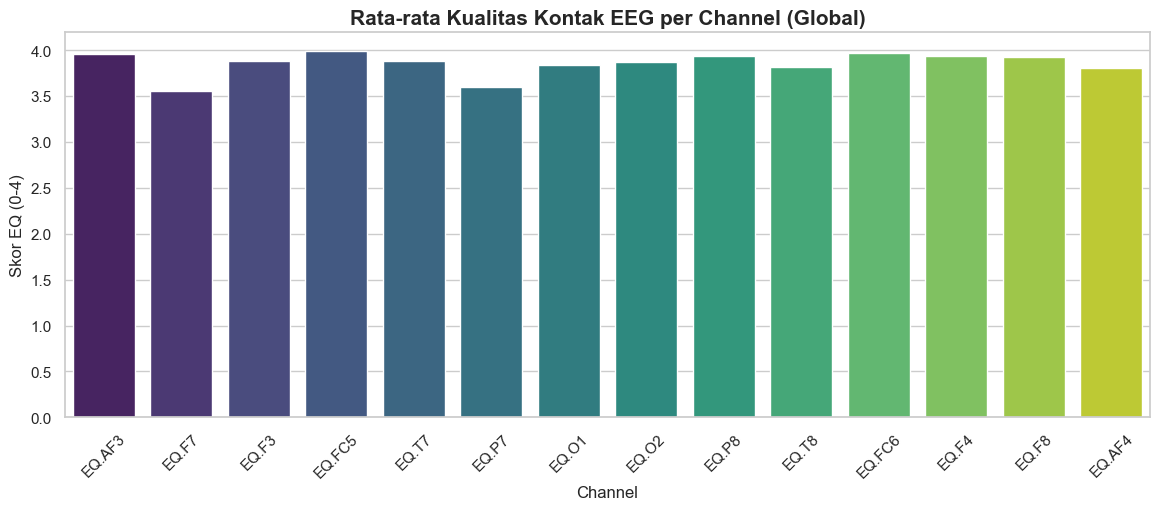

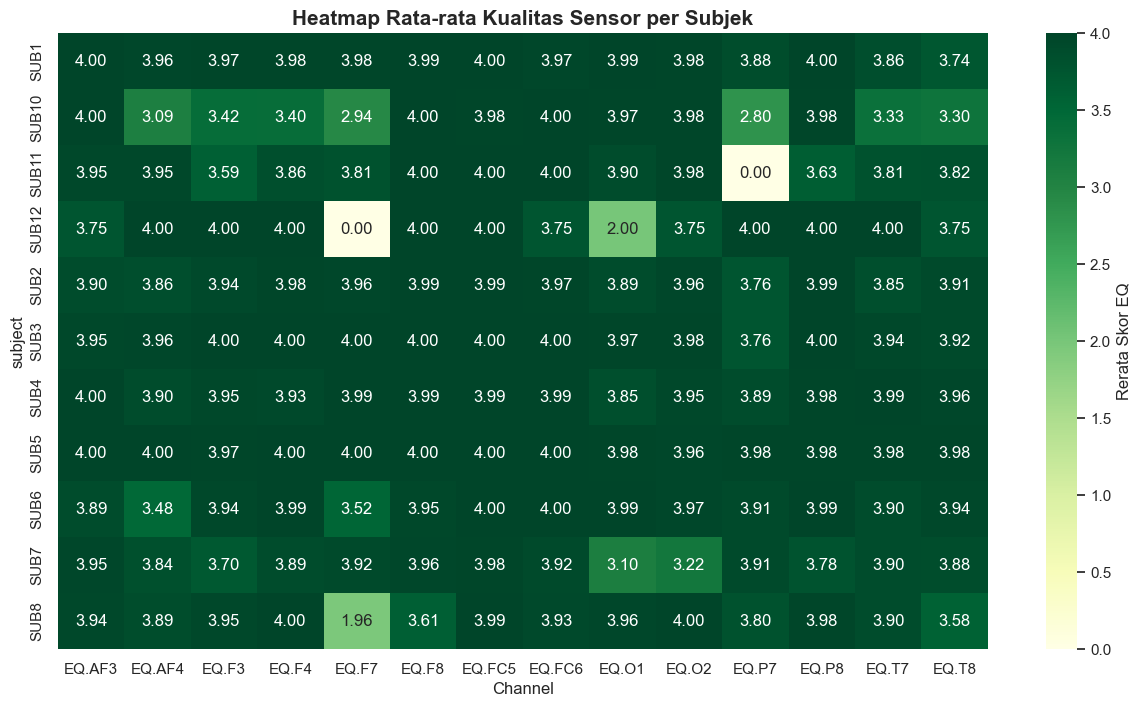


VISUALISASI DISTRIBUSI KUALITAS (14 DISTRIBUSI PER SUBJEK)


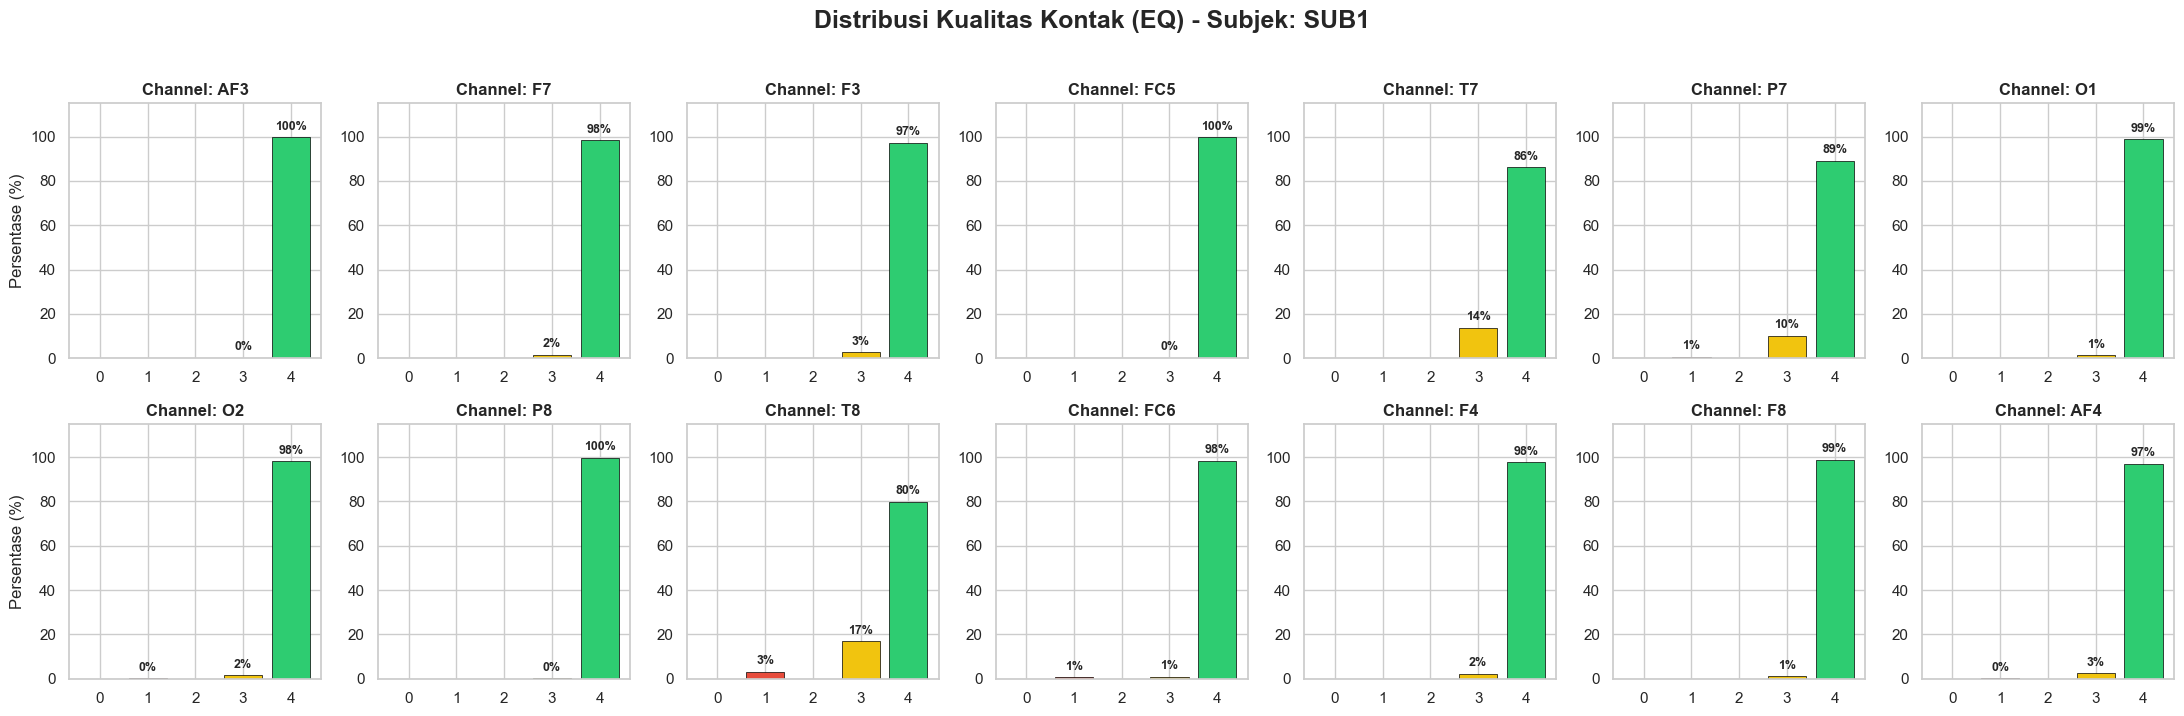

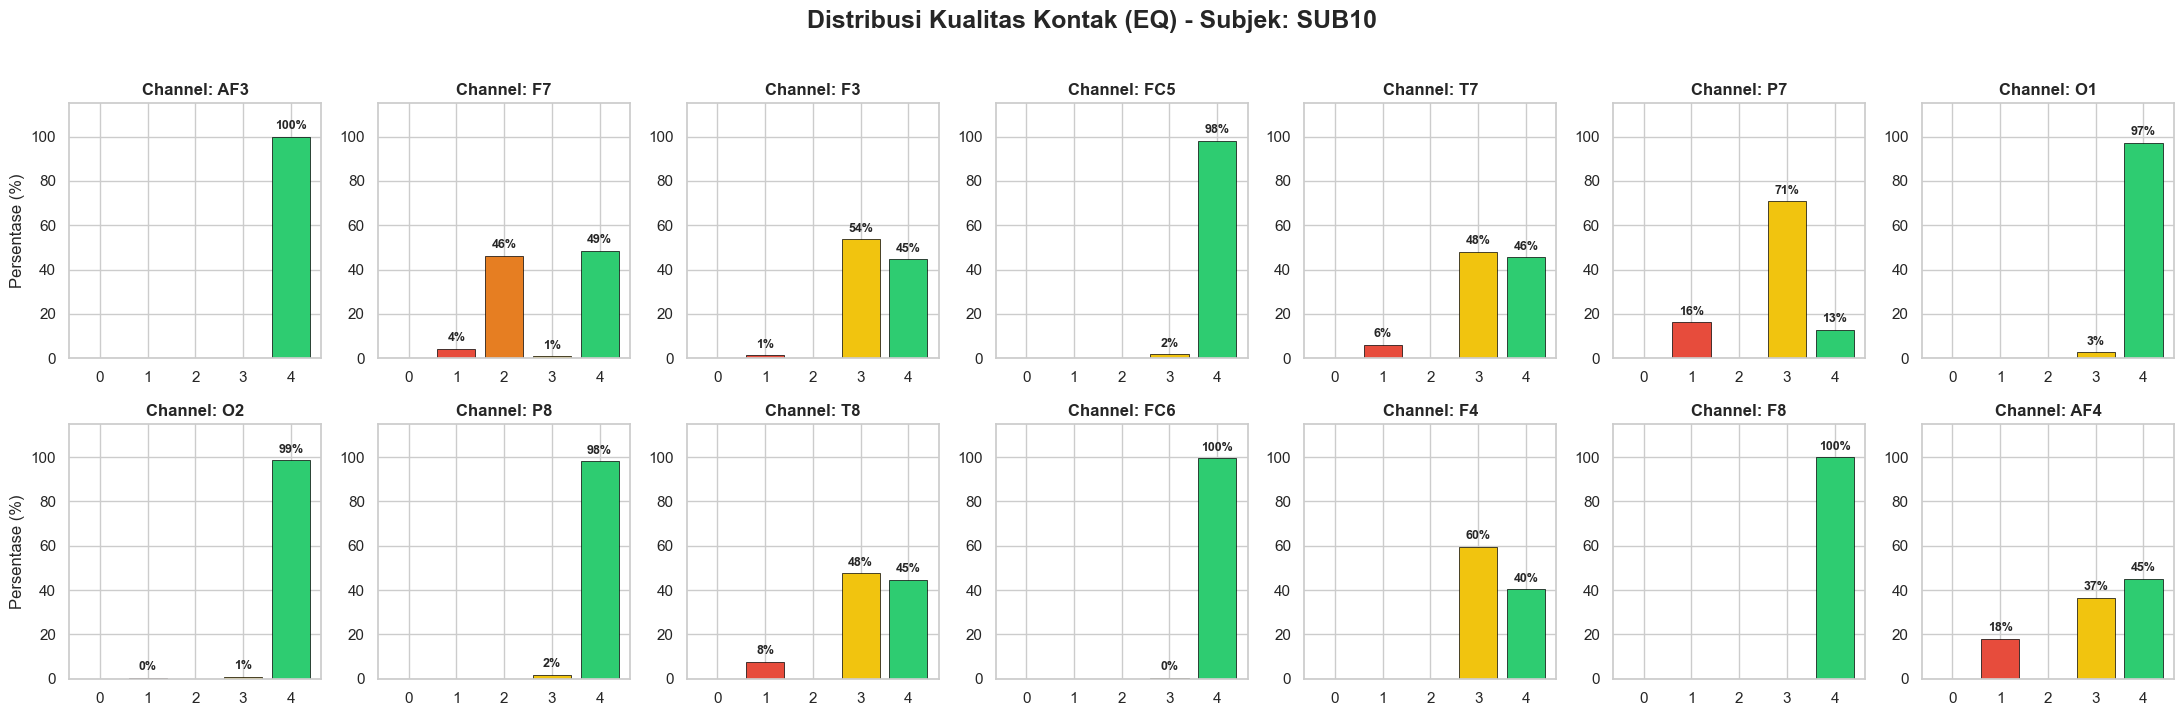

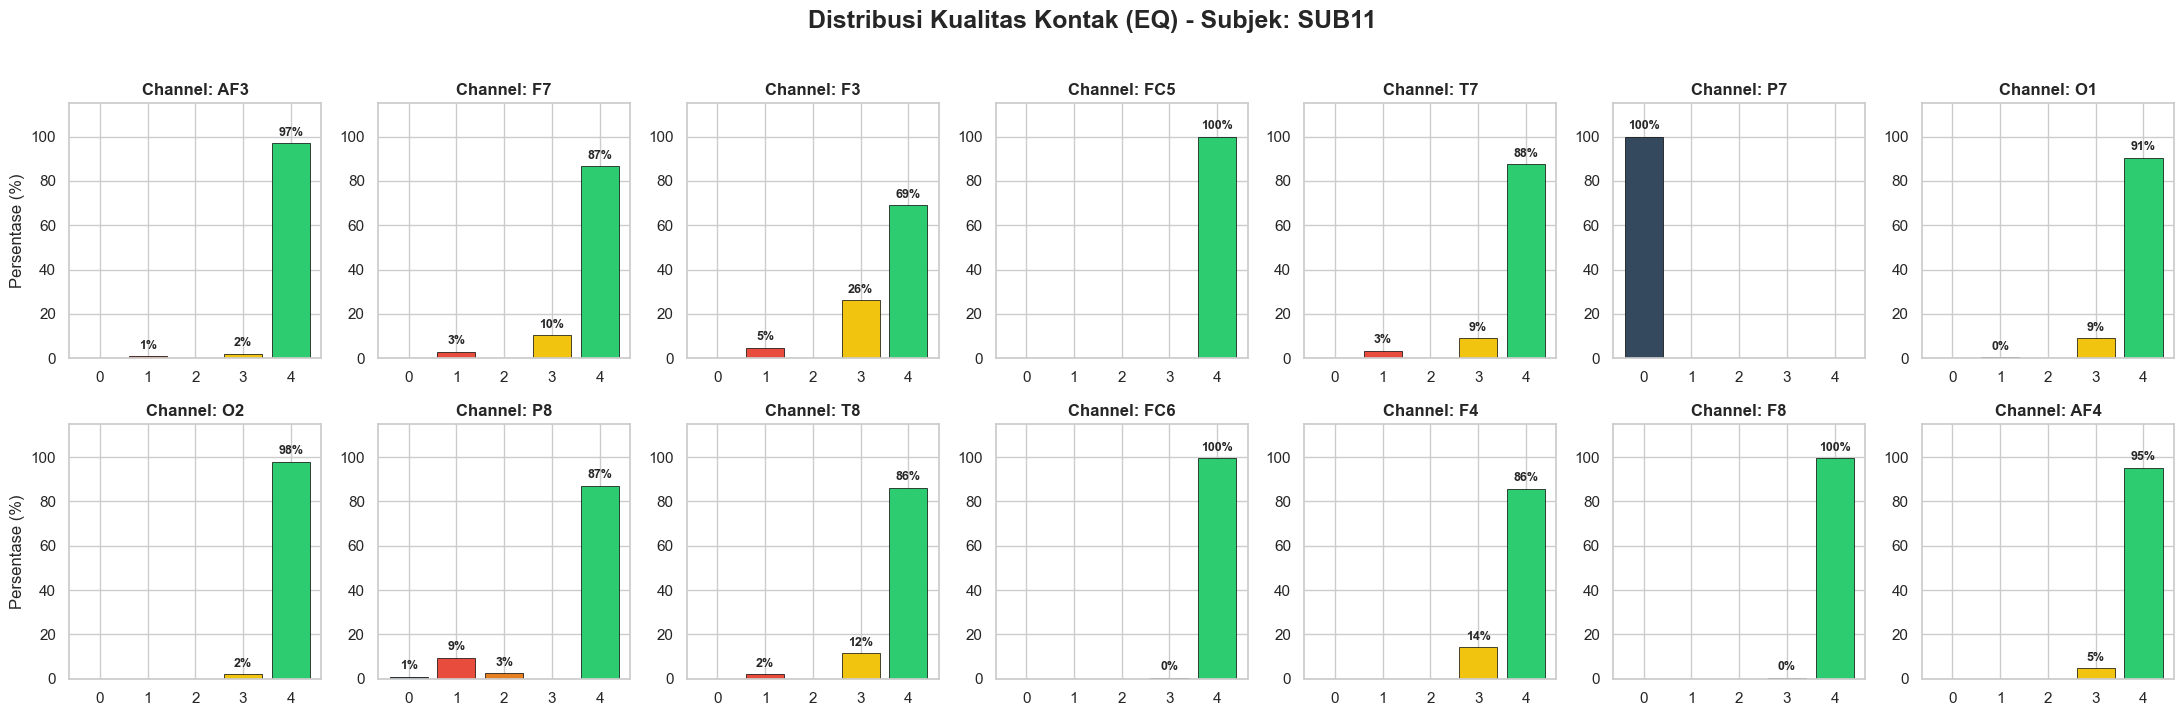

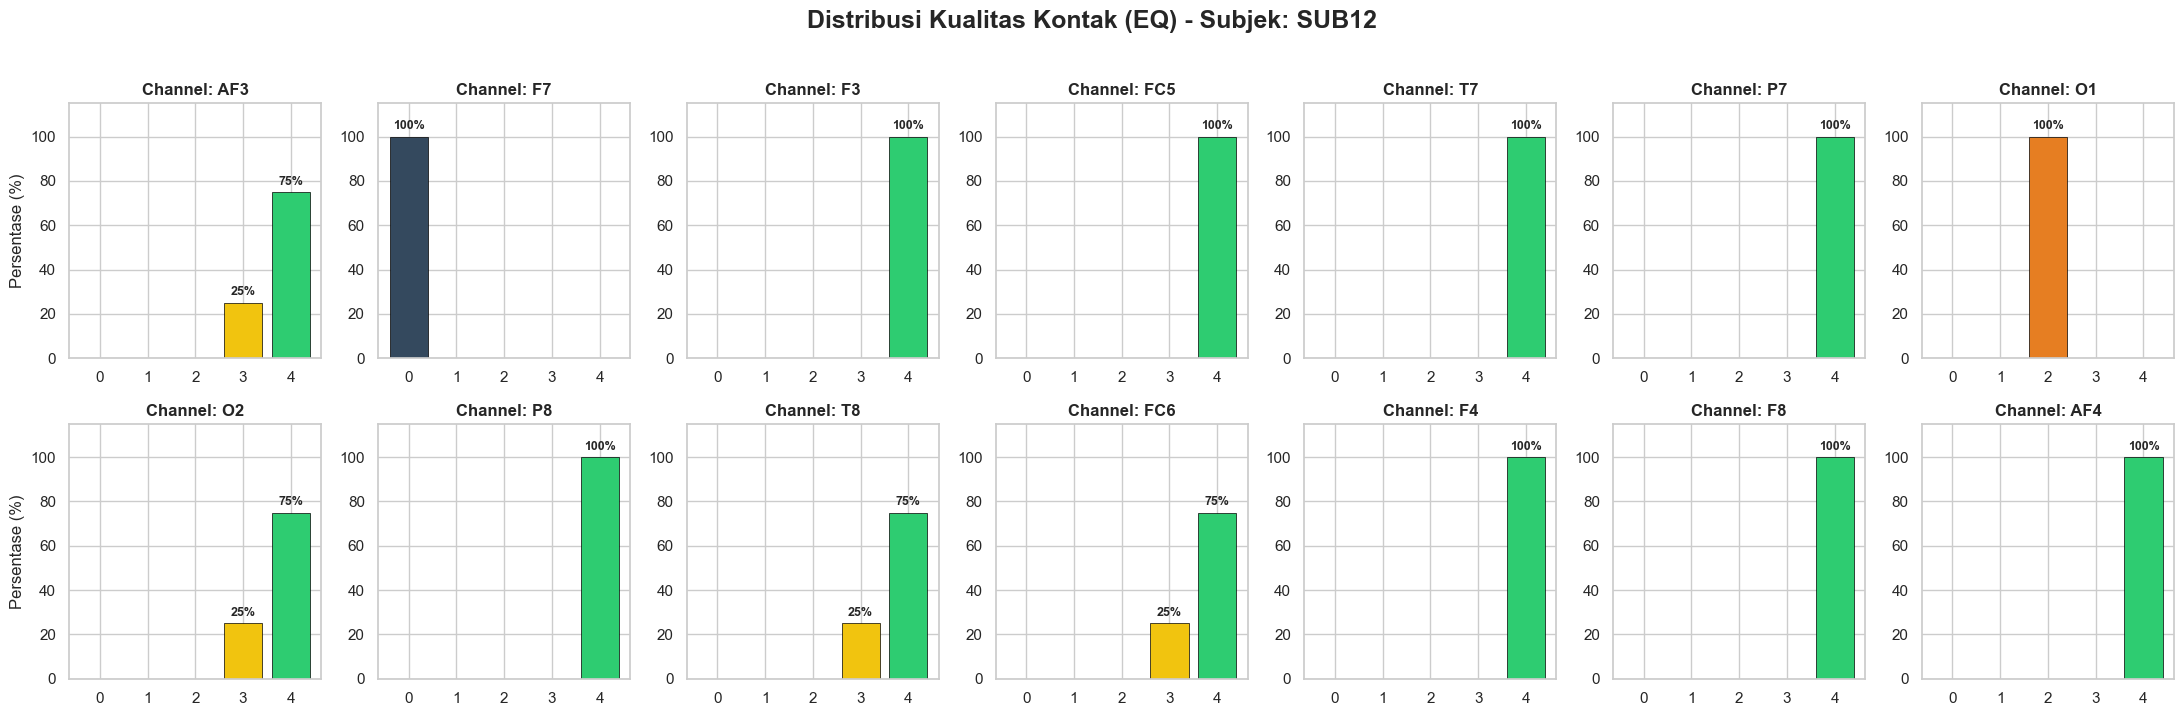

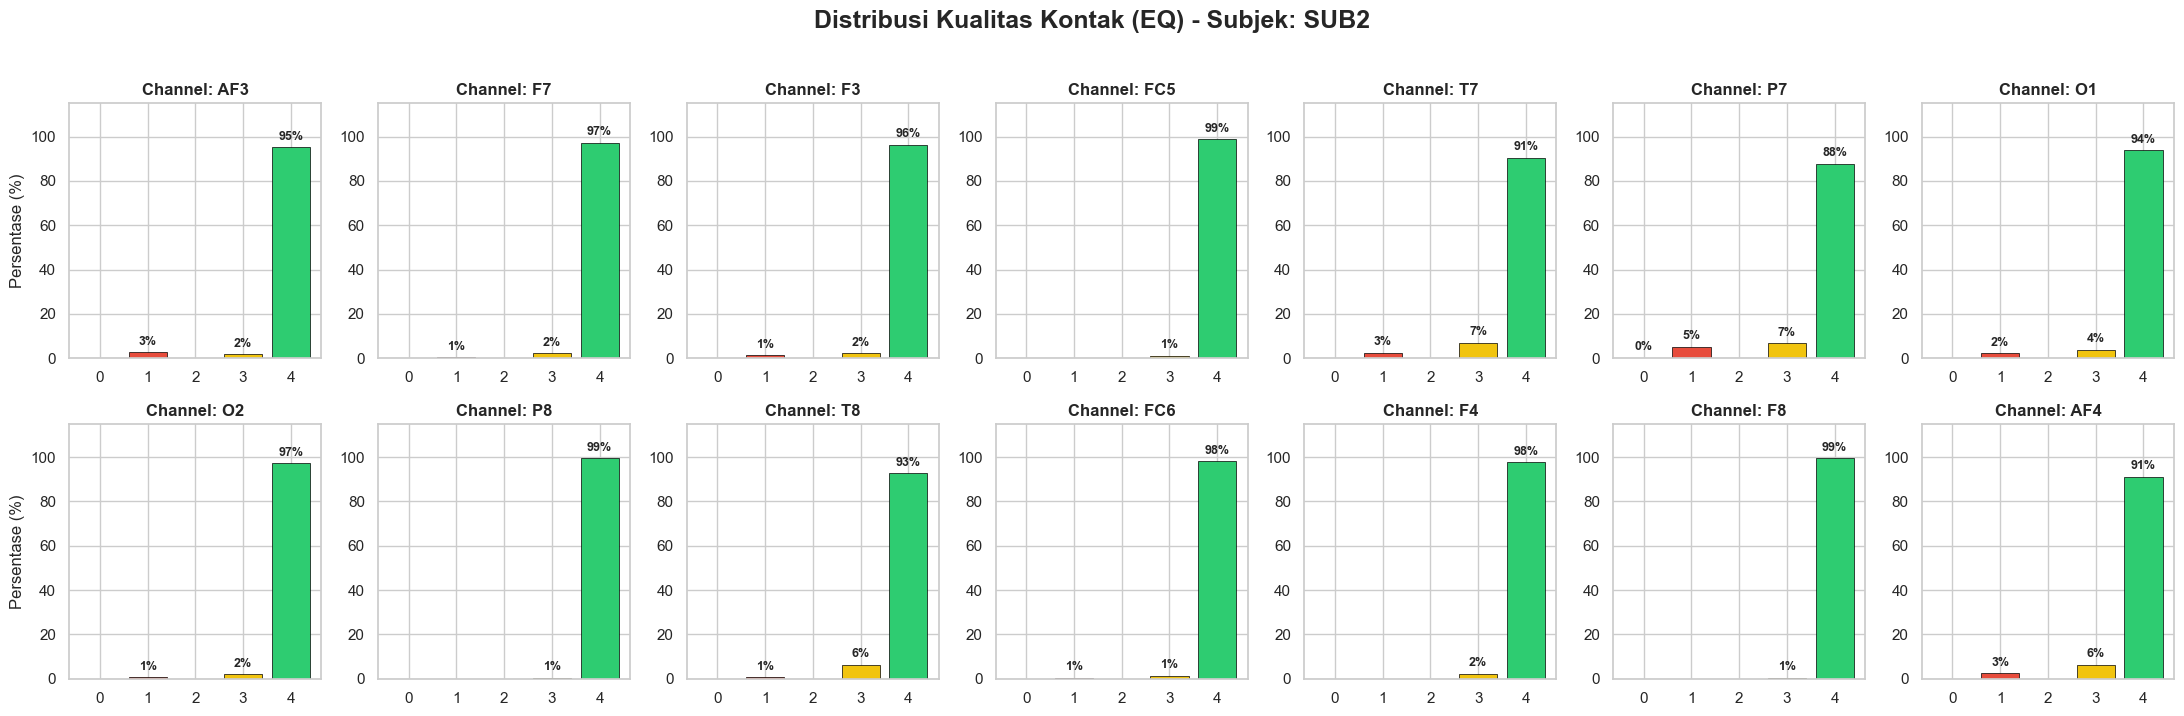

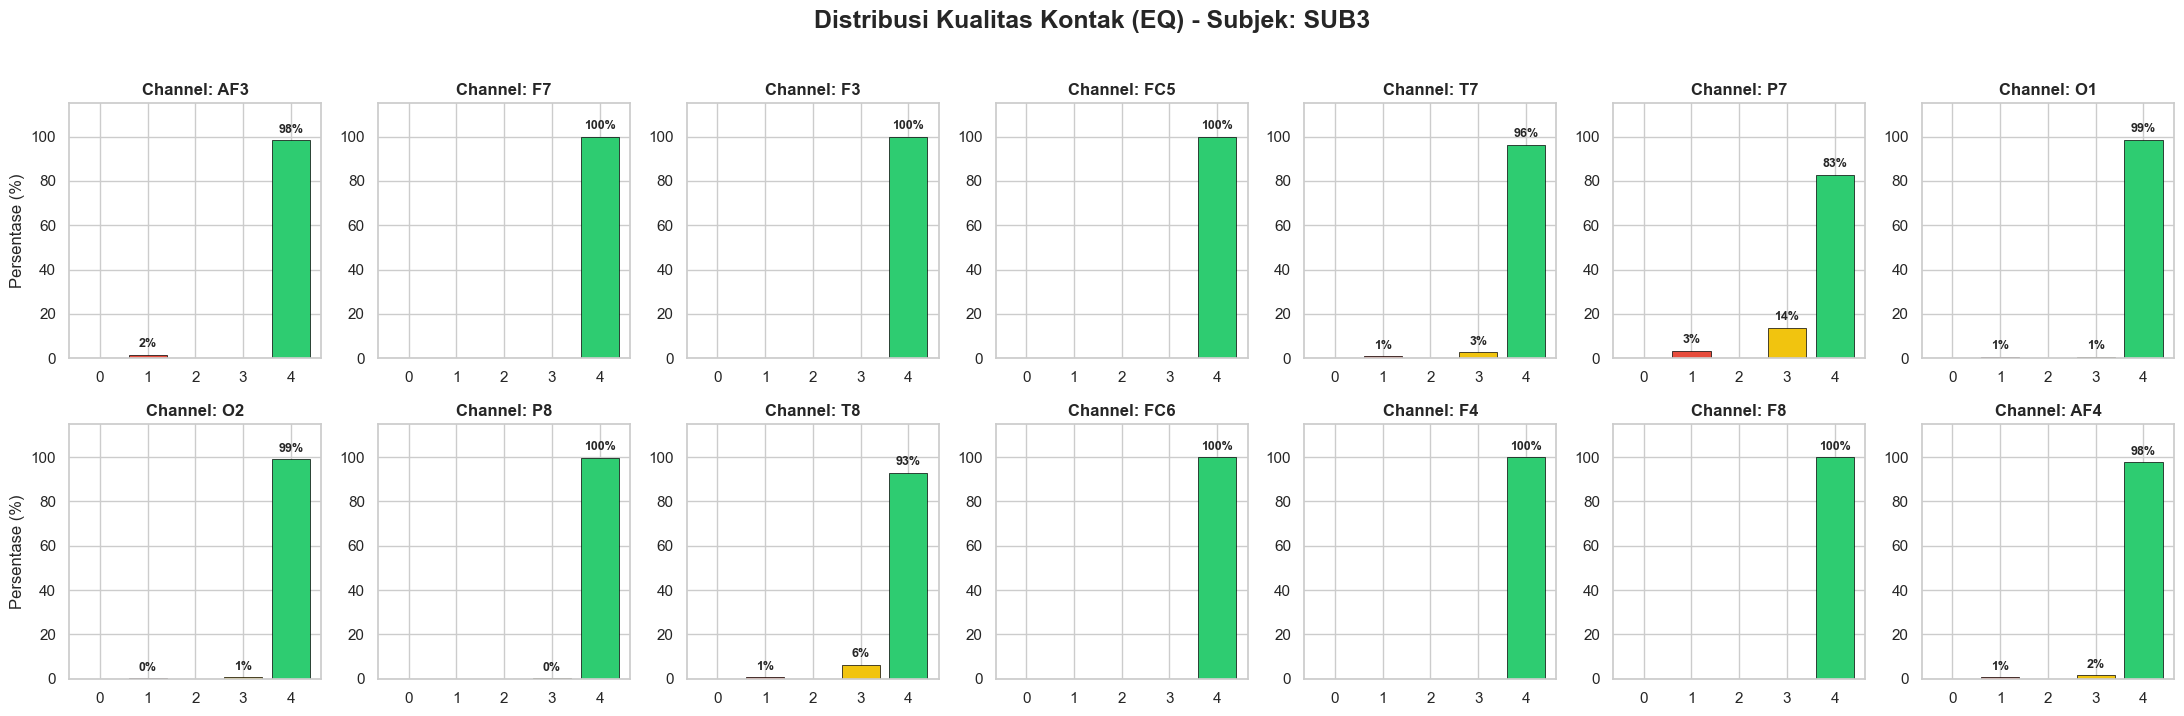

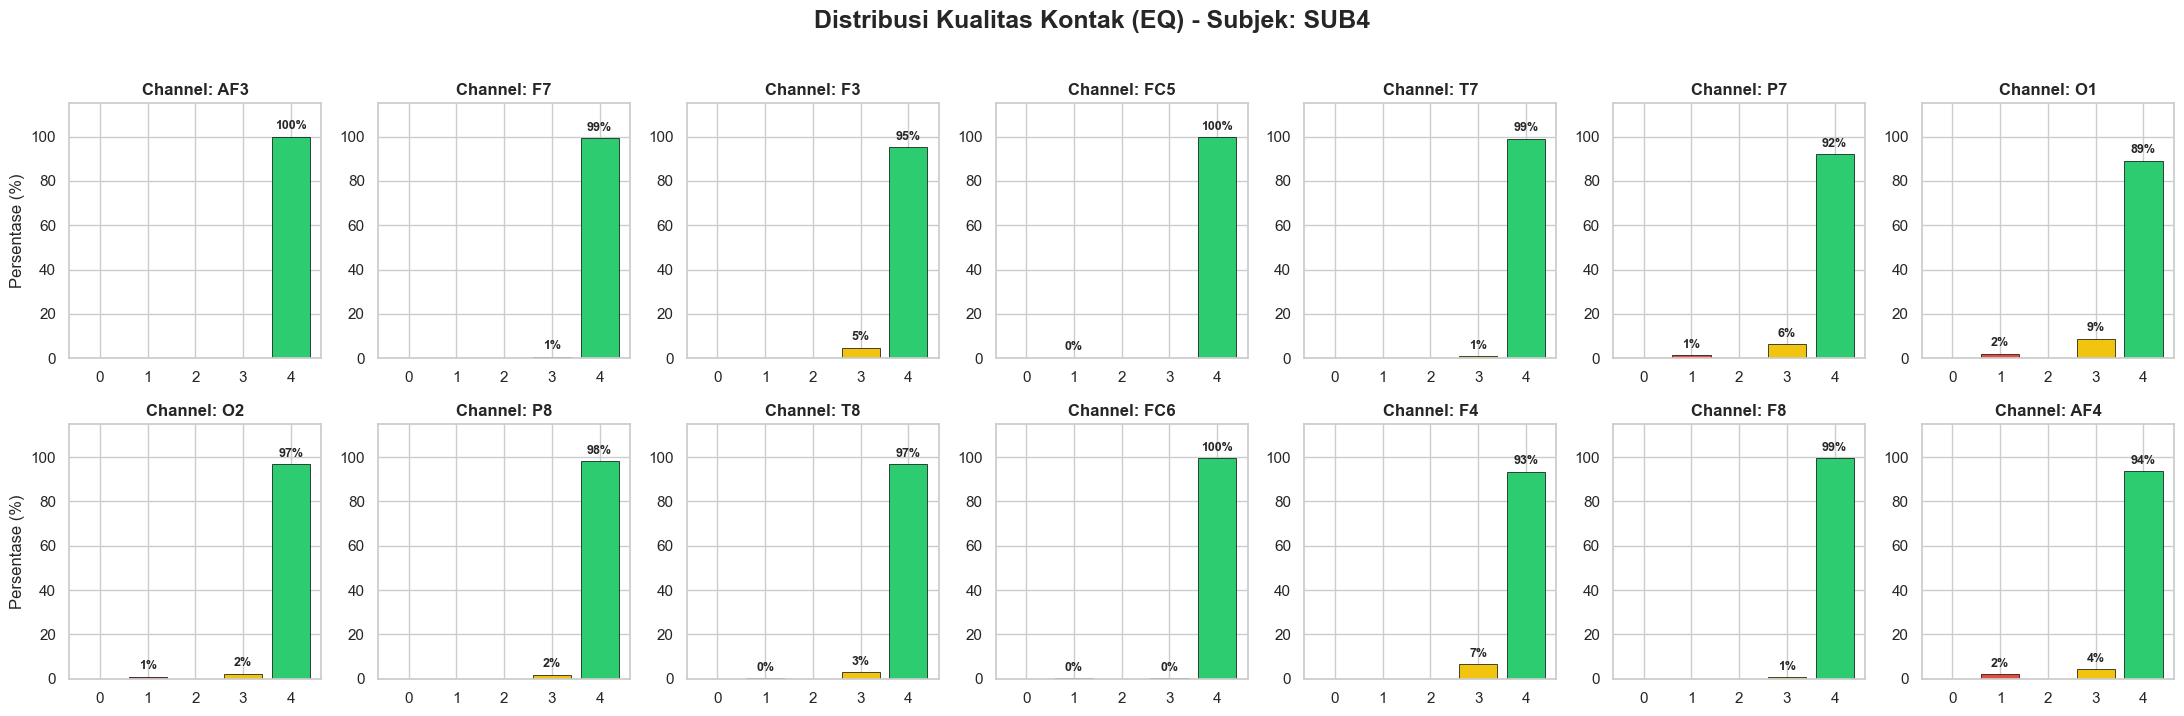

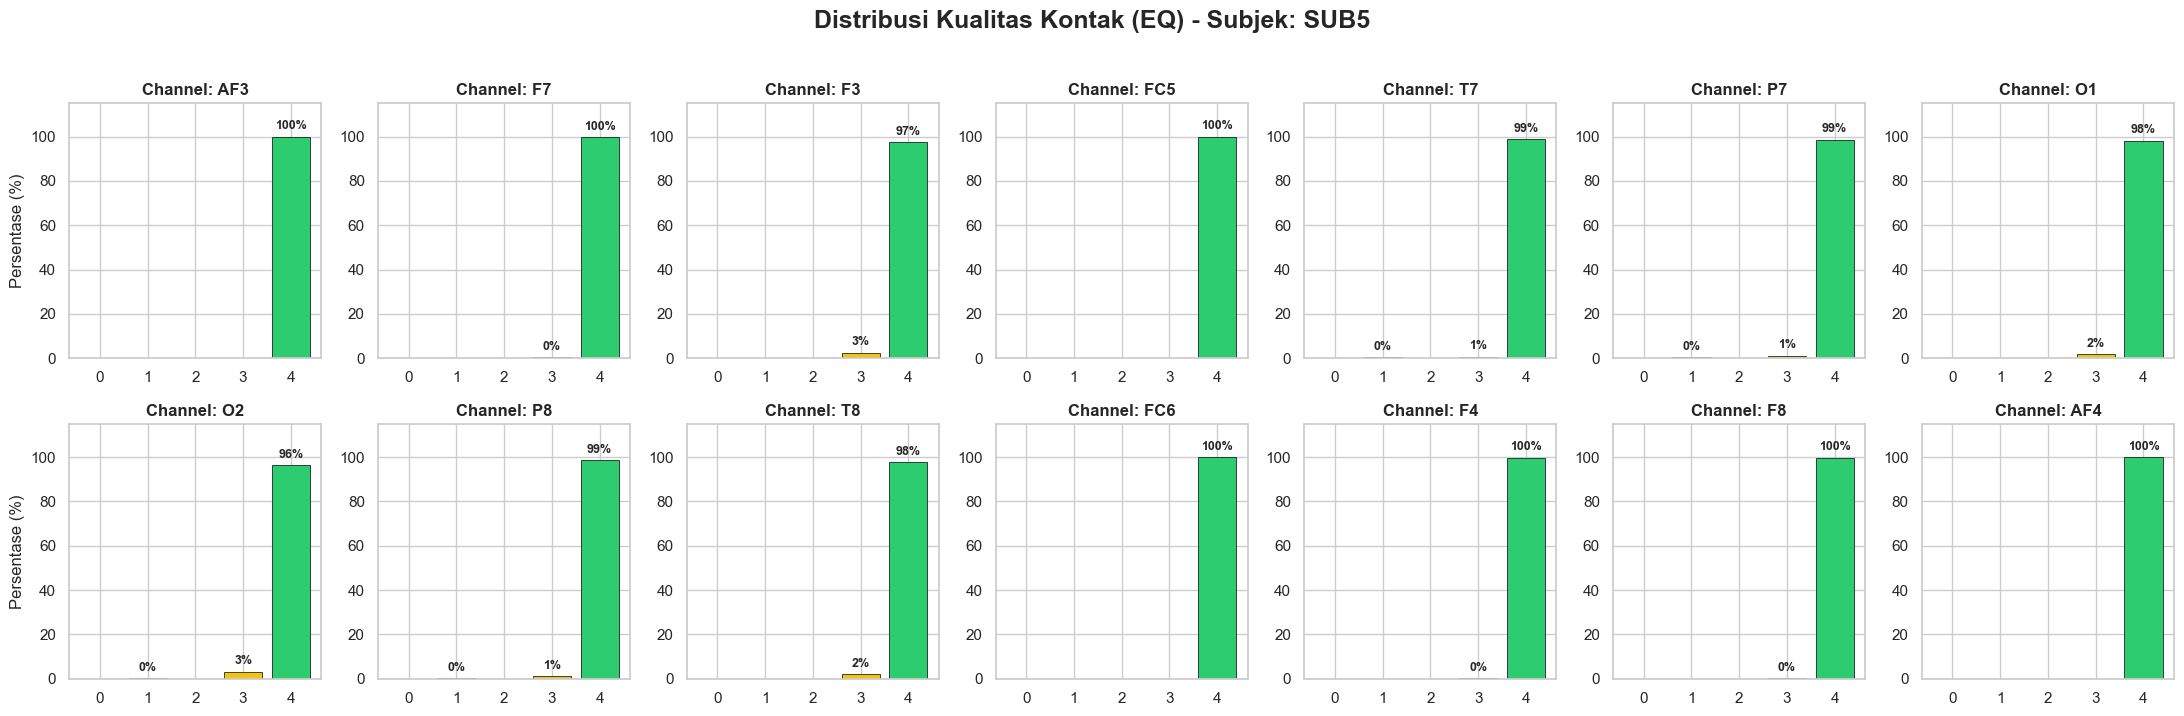

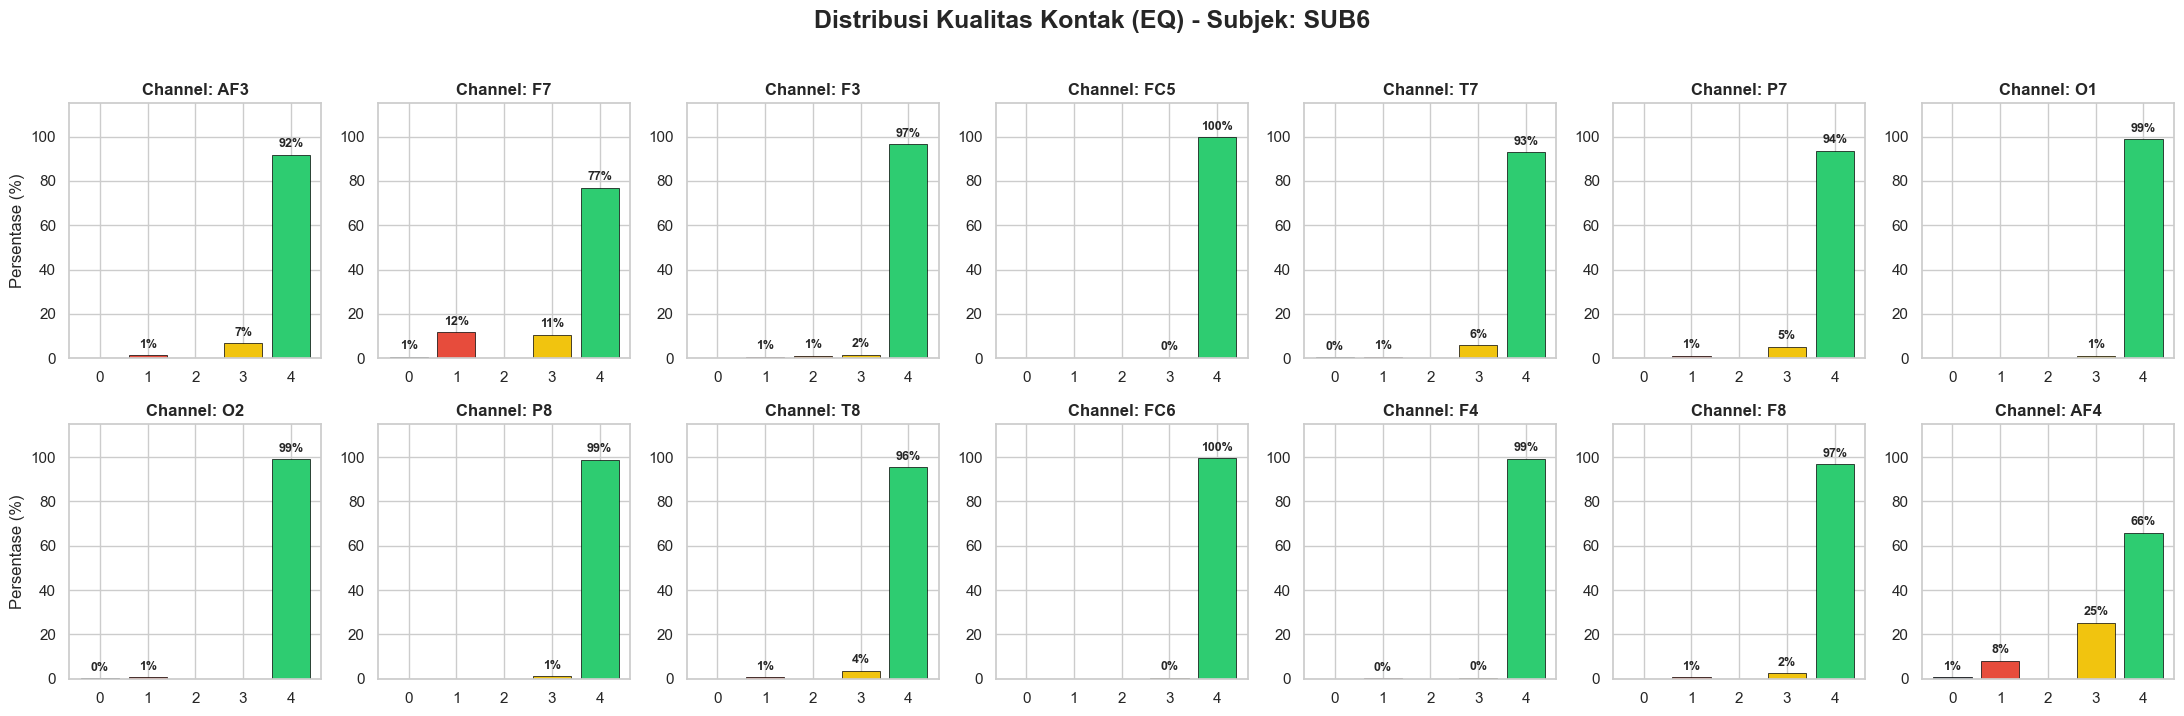

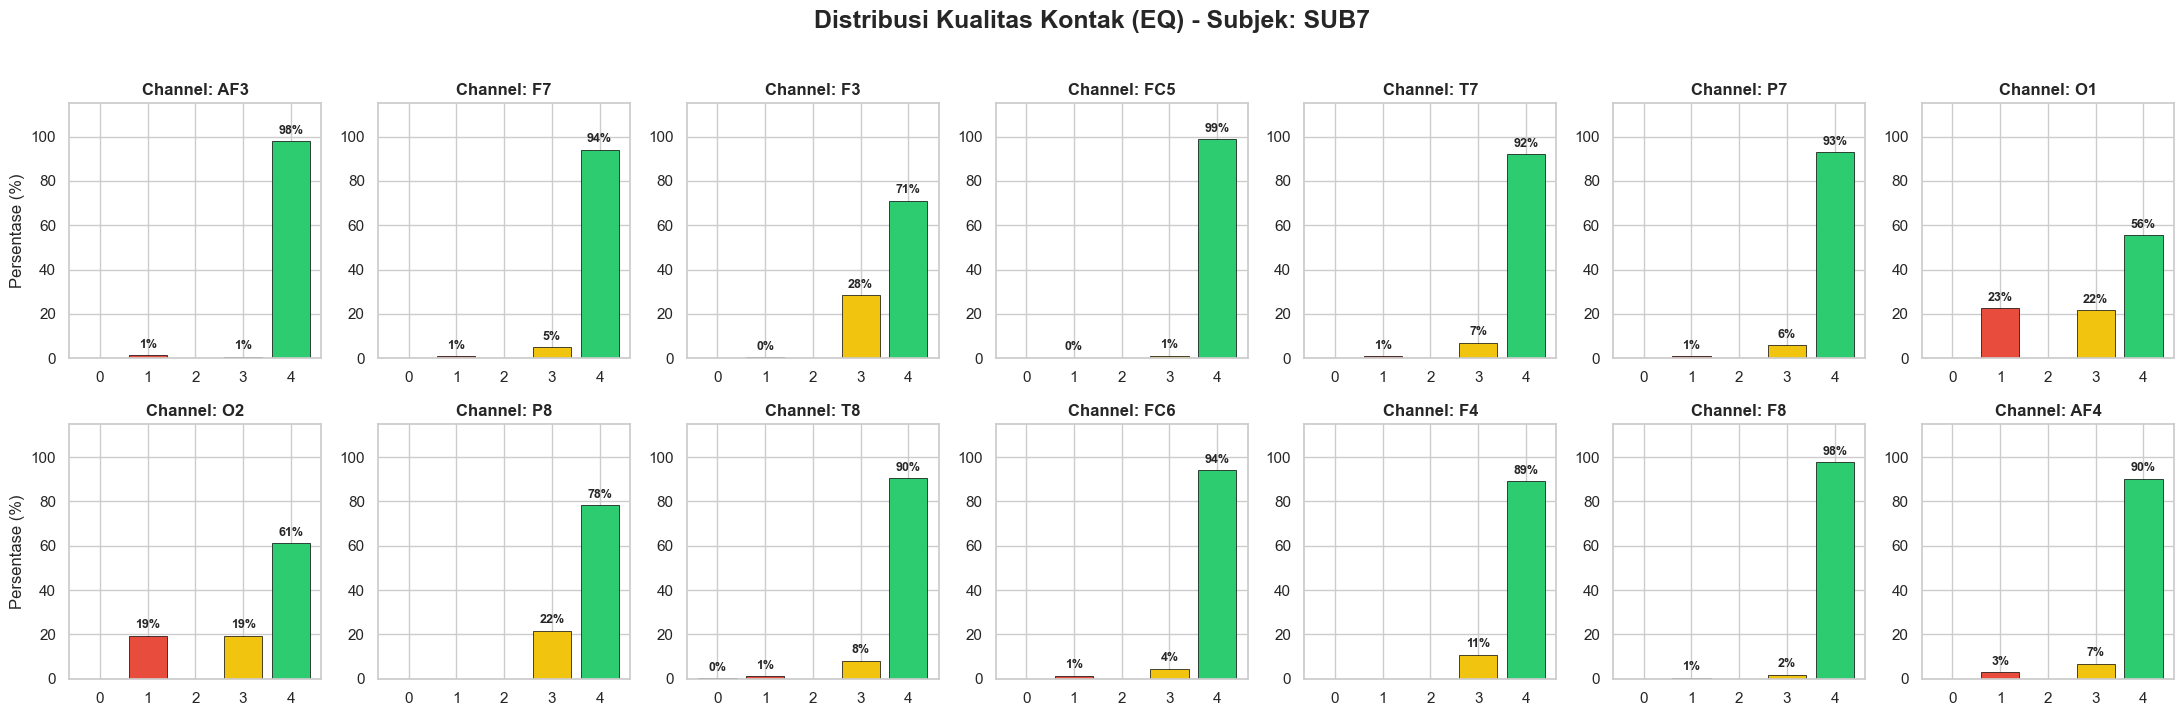

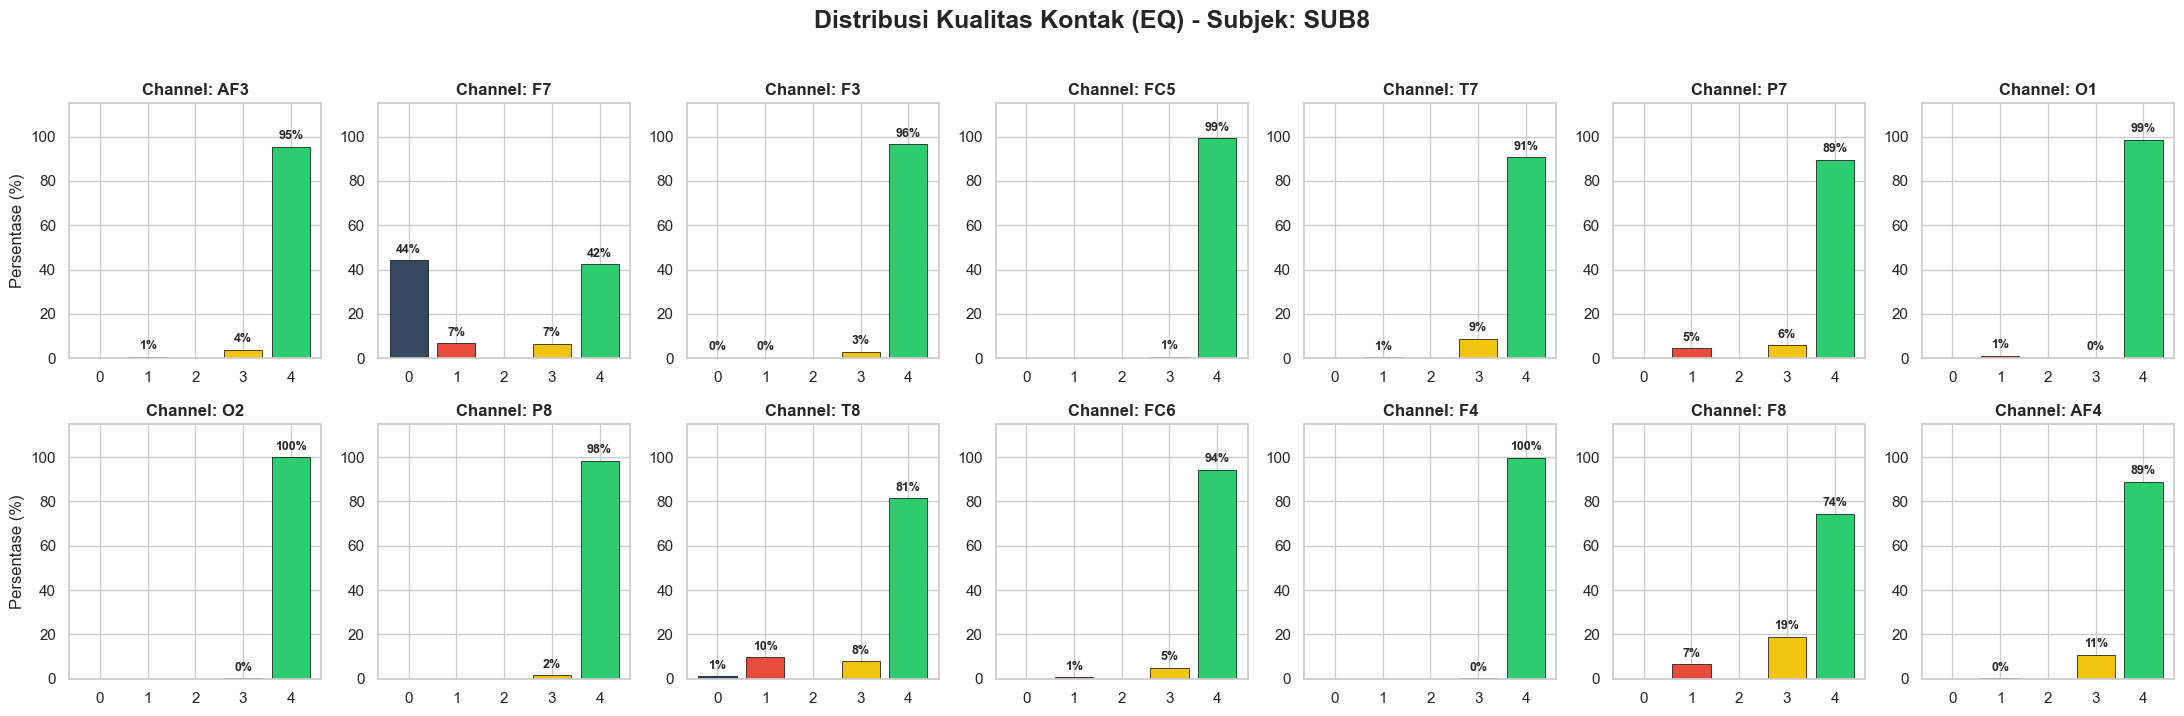


DAFTAR REKAMAN DIURUTKAN DARI RATA-RATA EEG QUALITY TERENDAH (SEMUA CHANNEL)
    id_rekaman subject    avg_eq
0    100_SUB10   SUB10  3.452381
1     98_SUB10   SUB10  3.452381
2     93_SUB10   SUB10  3.452381
3      92_SUB7    SUB7  3.452381
4     37_SUB10   SUB10  3.452381
5       8_SUB8    SUB8  3.455357
6     62_SUB10   SUB10  3.457143
7     92_SUB10   SUB10  3.459184
8     80_SUB11   SUB11  3.464286
9      33_SUB8    SUB8  3.464286
10    75_SUB11   SUB11  3.464286
11    67_SUB11   SUB11  3.464286
12    42_SUB10   SUB10  3.469388
13    29_SUB11   SUB11  3.469388
14     10_SUB8    SUB8  3.476190
15    23_SUB11   SUB11  3.476190
16    31_SUB10   SUB10  3.476190
17     15_SUB8    SUB8  3.482143
18    24_SUB11   SUB11  3.485714
19    97_SUB11   SUB11  3.485714
20    77_SUB10   SUB10  3.488095
21    74_SUB11   SUB11  3.488095
22     55_SUB7    SUB7  3.488095
23     40_SUB7    SUB7  3.488095
24      7_SUB8    SUB8  3.488095
25    43_SUB10   SUB10  3.488095
26    25_SUB11   SUB11  3.48809

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math

# ==========================================================
# 1. INISIALISASI PATH & KONFIGURASI
# ==========================================================
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '../../../'))
cleaned_csv_path = os.path.join(project_root, 'dataset/cleaned_transcript_mapping_eq_3_5.csv')
raw_data_path = os.path.join(project_root, 'dataset/raw')

df_map = pd.read_csv(cleaned_csv_path)

# Daftar Channel EEG asli
eeg_channels_raw = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
# Prefix EQ sesuai struktur file CSV
cq_channels = [f"EQ.{ch}" for ch in eeg_channels_raw]

quality_list = []
file_avg_quality = []

print("=" * 80)
print(" MEMULAI ANALISIS KUALITAS SINYAL EEG (CSV)")
print("=" * 80)

# ==========================================================
# 2. ITERASI & EKSTRAKSI DATA KUALITAS
# ==========================================================
for index, row in df_map.iterrows():
    id_val, subject, gender = row['id'], row['subject'], row['gender']
    csv_folder = os.path.join(raw_data_path, gender, subject, 'csv')
    
    if not os.path.isdir(csv_folder): continue
    matching_files = [f for f in os.listdir(csv_folder) if f.startswith(id_val + '_') and f.endswith('.bp.csv')]
    
    if matching_files:
        file_path = os.path.join(csv_folder, matching_files[0])
        try:
            # Memuat kolom EQ
            df_eeg = pd.read_csv(file_path, skiprows=1)
            avail_cq = [c for c in cq_channels if c in df_eeg.columns]
            
            if avail_cq:
                # Ambil data untuk distribusi (quality_list)
                df_temp = df_eeg[avail_cq].copy()
                df_temp['subject'] = subject
                df_temp['file_id'] = id_val
                quality_list.append(df_temp)
                
                # Hitung rata-rata EQ untuk file ini (semua channel)
                # Mean pertama: rata-rata per channel, Mean kedua: rata-rata seluruh channel di file tsb
                avg_val = df_eeg[avail_cq].mean().mean()
                file_avg_quality.append({
                    'id_rekaman': id_val,
                    'subject': subject,
                    'avg_eq': avg_val
                })
        except: continue

# Dataframe untuk distribusi global
df_qual_all = pd.concat(quality_list, ignore_index=True)
df_q_melt = df_qual_all.melt(id_vars=['subject', 'file_id'], var_name='Channel', value_name='Score')

# Dataframe untuk rata-rata per file
df_file_avg = pd.DataFrame(file_avg_quality)

# ==========================================================
# 3. VISUALISASI 1: GLOBAL QUALITY (BARPLOT RATA-RATA)
# ==========================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))
sns.barplot(data=df_q_melt, x='Channel', y='Score', palette='viridis', errorbar=None)
plt.title('Rata-rata Kualitas Kontak EEG per Channel (Global)', fontsize=15, fontweight='bold')
plt.ylabel('Skor EQ (0-4)')
plt.xticks(rotation=45)
plt.show()

# ==========================================================
# 4. VISUALISASI 2: HEATMAP PER SUBJEK (RATA-RATA)
# ==========================================================
plt.figure(figsize=(15, 8))
df_pivot = df_q_melt.groupby(['subject', 'Channel'])['Score'].mean().unstack()
sns.heatmap(df_pivot, annot=True, cmap='YlGn', fmt=".2f", cbar_kws={'label': 'Rerata Skor EQ'})
plt.title('Heatmap Rata-rata Kualitas Sensor per Subjek', fontsize=15, fontweight='bold')
plt.show()

# ==========================================================
# 5. VISUALISASI 3: DISTRIBUSI KUALITAS (BAR CHART PERSENTASE PER SUBJEK)
# ==========================================================
print("\n" + "=" * 100)
print("VISUALISASI DISTRIBUSI KUALITAS (14 DISTRIBUSI PER SUBJEK)")
print("=" * 100)

emotiv_colors = {4.0: '#2ecc71', 3.0: '#f1c40f', 2.0: '#e67e22', 1.0: '#e74c3c', 0.0: '#34495e'}
unique_subjects = sorted(df_qual_all['subject'].unique())

for subj in unique_subjects:
    subj_raw_data = df_qual_all[df_qual_all['subject'] == subj]
    fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(22, 7))
    fig.suptitle(f"Distribusi Kualitas Kontak (EQ) - Subjek: {subj}", fontsize=18, fontweight='bold', y=1.02)
    axes = axes.flatten()
    
    for idx, ch_name in enumerate(eeg_channels_raw):
        ax = axes[idx]
        col_name = f"EQ.{ch_name}"
        counts = {0.0: 0, 1.0: 0, 2.0: 0, 3.0: 0, 4.0: 0}
        
        if col_name in subj_raw_data.columns:
            vals = subj_raw_data[col_name].dropna().values
            if len(vals) > 0:
                unique, cnts = np.unique(np.round(vals), return_counts=True)
                for u, c in zip(unique, cnts):
                    if u in counts: counts[u] += c
                total = sum(counts.values())
                pcts = {k: (v/total)*100 for k, v in counts.items()}
            else: pcts = {k: 0 for k in counts.keys()}
        else: pcts = {k: 0 for k in counts.keys()}
            
        x_labels = ['0', '1', '2', '3', '4']
        y_vals = [pcts[0.0], pcts[1.0], pcts[2.0], pcts[3.0], pcts[4.0]]
        colors = [emotiv_colors[v] for v in [0.0, 1.0, 2.0, 3.0, 4.0]]
        
        ax.bar(x_labels, y_vals, color=colors, edgecolor='black', linewidth=0.5)
        ax.set_title(f"Channel: {ch_name}", fontsize=12, fontweight='bold')
        ax.set_ylim(0, 115)
        if idx % 7 == 0: ax.set_ylabel("Persentase (%)")
        
        for i, v in enumerate(y_vals):
            if v > 0: ax.text(i, v + 2, f"{v:.0f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

# ==========================================================
# 6. DAFTAR REKAMAN BERDASARKAN RATA-RATA EQ TERENDAH
# ==========================================================
print("\n" + "=" * 100)
print("DAFTAR REKAMAN DIURUTKAN DARI RATA-RATA EEG QUALITY TERENDAH (SEMUA CHANNEL)")
print("=" * 100)

# Mengurutkan dari yang terkecil (ascending)
df_sorted_eq = df_file_avg.sort_values(by='avg_eq', ascending=True).reset_index(drop=True)

# Menampilkan 50 data pertama sebagai contoh atau seluruhnya
print(df_sorted_eq.to_string())